In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
data = pd.read_csv('2023-03-08 Precios Casas RM.csv')
data.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


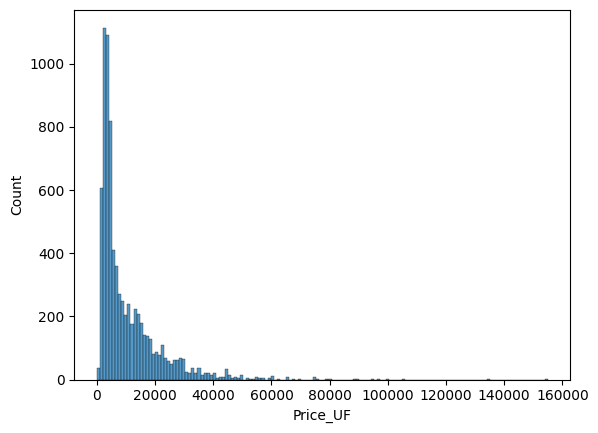

In [75]:
sns.histplot(data["Price_UF"])
plt.show()

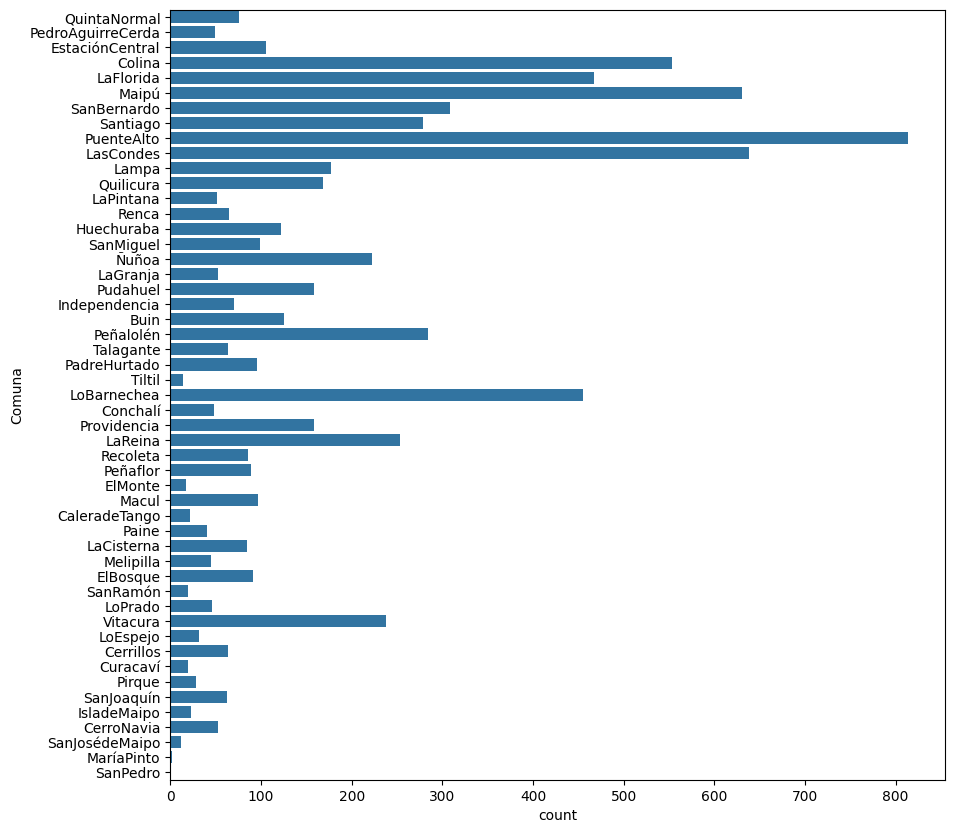

In [76]:
plt.figure(figsize=(10, 10))
sns.countplot(data["Comuna"])
plt.show()

<Axes: xlabel='Total Area', ylabel='Price_UF'>

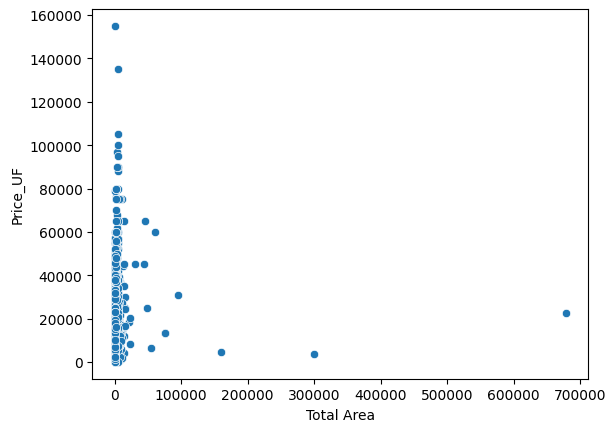

In [77]:
sns.scatterplot(x=data["Total Area"], y=data["Price_UF"])

<Axes: xlabel='Dorms', ylabel='Price_UF'>

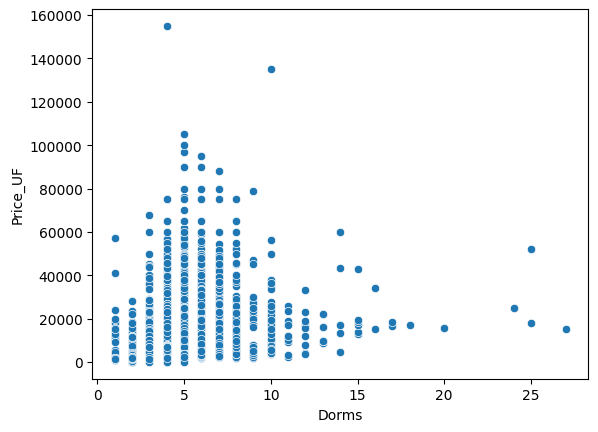

In [78]:
sns.scatterplot(x=data["Dorms"], y=data["Price_UF"])

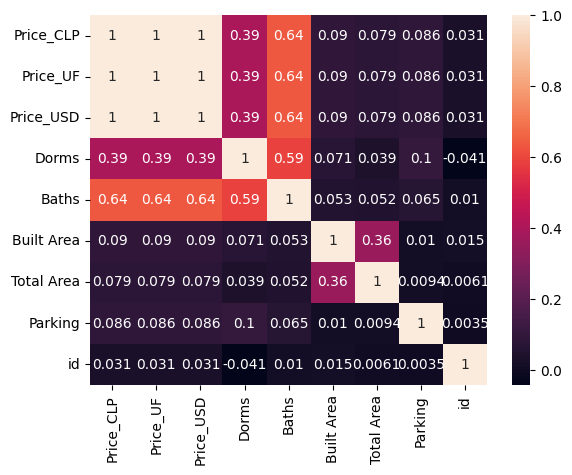

In [79]:
matriz_corre = data.corr(numeric_only=True)
sns.heatmap(matriz_corre, annot=True)   
plt.show()

<Axes: xlabel='Baths', ylabel='Count'>

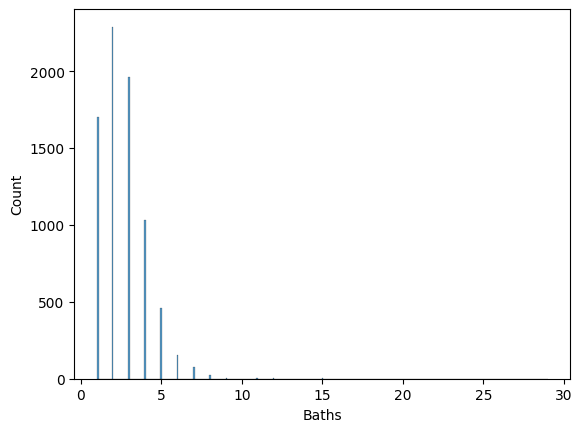

In [80]:
sns.histplot(data["Baths"])

<Axes: xlabel='Parking', ylabel='Count'>

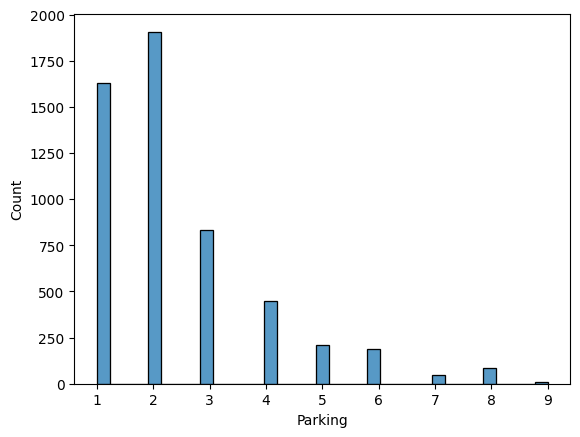

In [81]:
sns.histplot(data[data["Parking"]<10]["Parking"])

<Axes: xlabel='Baths', ylabel='Count'>

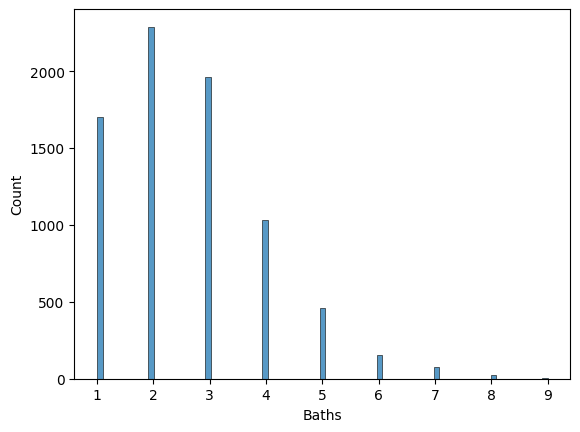

In [82]:
sns.histplot(data[data["Baths"]<10]["Baths"])

In [83]:
data = data.drop(columns=["Price_CLP", "Price_USD","Ubicacion","id","Realtor","Comuna"])
data

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking
0,11500,7,4.0,384.0,732.0,3.0
1,2950,2,1.0,112.0,145.0,1.0
2,3600,3,1.0,59.0,243.0,2.0
3,2107,3,1.0,103.0,73.0,1.0
4,1489,2,1.0,57.0,67.0,1.0
...,...,...,...,...,...,...
7774,70000,5,5.0,600.0,1800.0,5.0
7775,6800,4,2.0,124.0,200.0,1.0
7776,105000,5,7.0,460.0,4925.0,8.0
7777,16000,4,2.0,311.0,2011.0,1.0


In [84]:
from sklearn.impute import KNNImputer #imputar datos faltantes


In [85]:
imputer = KNNImputer(n_neighbors=5) #utliza los vecinos mas cercanos para imputar los datos faltantes
data_imputed = imputer.fit_transform(data)
data_imputed = pd.DataFrame(data_imputed, columns=data.columns)
data_imputed

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking
0,11500.0,7.0,4.0,384.0,732.0,3.0
1,2950.0,2.0,1.0,112.0,145.0,1.0
2,3600.0,3.0,1.0,59.0,243.0,2.0
3,2107.0,3.0,1.0,103.0,73.0,1.0
4,1489.0,2.0,1.0,57.0,67.0,1.0
...,...,...,...,...,...,...
7774,70000.0,5.0,5.0,600.0,1800.0,5.0
7775,6800.0,4.0,2.0,124.0,200.0,1.0
7776,105000.0,5.0,7.0,460.0,4925.0,8.0
7777,16000.0,4.0,2.0,311.0,2011.0,1.0


In [86]:
def iqr(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    max_val =q3 + 1.5*(q3-q1)
    min_val = q1 - 1.5*(q3-q1)
    x=x[(x>min_val) & (x<max_val)]
    return x
for col in data_imputed.columns:
    data_imputed[col] = iqr(data_imputed[col])
    

In [87]:
data_imputed = data_imputed.dropna() #elimina filas con valores faltantes despues de eliminar outliers

## Contruir modelo lineal

In [95]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler #estandarizar
from sklearn.pipeline import Pipeline #pipeline para encadenar procesos
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures


In [89]:
X= data_imputed.drop(columns=["Price_UF"]) #feautures
y= data_imputed["Price_UF"] #target

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_test.shape, y_test.shape

((4912, 5), (4912,), (1229, 5), (1229,), (1229, 5), (1229,))

In [91]:
pipeline = Pipeline([
    ('scaler', StandardScaler()), #estandarizar los datos
    ('model', LinearRegression()) #modelo de regresion lineal
])
pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [92]:
score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
score #sis da negativo es un modelo peor que la media 

array([0.68568288, 0.68470159, 0.7402607 , 0.63743483, 0.63450984])

In [97]:
pipeline = Pipeline([
    ('scaler', StandardScaler()), #estandarizar los datos
    ('Poly', PolynomialFeatures(degree=2)), #modelo de regresion lineal
    ('model', LinearRegression())   
])
pipeline

,steps,"[('scaler', ...), ('Poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
